# Walmart Retail Sales - XGBoost Regressor (Final Correct Pipeline)
**Author:** Rishikesh K Sivaji

---
### Pipeline
```
Feature Engineering
       ↓
TimeSeriesSplit CV (Hyperparameter Tuning)
       ↓
XGBRegressor (train on full training data)
       ↓
Predict Weekly_Sales
       ↓
RMSE / MAE / MAPE / WMAE
```

---
### Sections
1. Load Data and Setup
2. Train-Test Split
3. Feature Selection
4. Evaluation Metrics
5. Baseline — Linear Regression
6. TimeSeriesSplit CV — Hyperparameter Tuning
7. Train Final XGBoost on Full Training Data
8. Final Model Evaluation
9. Feature Importance
10. Actual vs Predicted
11. Ablation Tests
12. Model Summary


## 1. Load Data and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
PALETTE = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6']
print('Libraries loaded')


Libraries loaded


In [2]:
df = pd.read_csv('data/model_df.csv', parse_dates=['Date'])
df = df.sort_values(['Store','Dept','Date']).reset_index(drop=True)

print(f'Shape       : {df.shape}')
print(f'Date range  : {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Null values : {df.isnull().sum().sum()}')


Shape       : (421570, 54)
Date range  : 2010-02-05 to 2012-10-26
Null values : 0


## 2. Train-Test Split

Strict date-based split — the model never sees future data during training.

- **Train:** Feb 2010 to Jul 2012 (90.9%)
- **Test:** Aug 2012 to Oct 2012 (9.1%) — held out until final evaluation only


In [3]:
TRAIN_END  = '2012-07-27'
TEST_START = '2012-08-03'

train = df[df['Date'] <= TRAIN_END].copy()
test  = df[df['Date'] >= TEST_START].copy()

print(f'Train : {len(train):,} rows | {train["Date"].min().date()} to {train["Date"].max().date()}')
print(f'Test  : {len(test):,} rows  | {test["Date"].min().date()} to {test["Date"].max().date()}')
print(f'Train : {len(train)/len(df)*100:.1f}% of data')
print(f'Test  : {len(test)/len(df)*100:.1f}% of data')
print()
print('IMPORTANT: Test set is held out and never used during tuning or training')
print('It is only used once at the very end for final evaluation')


Train : 383,040 rows | 2010-02-05 to 2012-07-27
Test  : 38,530 rows  | 2012-08-03 to 2012-10-26
Train : 90.9% of data
Test  : 9.1% of data

IMPORTANT: Test set is held out and never used during tuning or training
It is only used once at the very end for final evaluation


## 3. Feature Selection

In [4]:
EXCLUDE = ['Store','Dept','Date','Weekly_Sales','Sales_Class',
           'Type','Month_Name','Holiday_Name','Unemp_Band',
           'Fuel_Band','StoreDept_Median',
           'lag_52',
           'lag_2',
           'lag_diff_1_2',
           'roll_mean_26',
           'roll_max_4',
           'roll_min_4',
           'roll_range_4']

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

X_train = train[FEATURE_COLS]
y_train = train['Weekly_Sales']
X_test  = test[FEATURE_COLS]
y_test  = test['Weekly_Sales']

print(f'Total features : {len(FEATURE_COLS)}')
print(f'X_train        : {X_train.shape}')
print(f'X_test         : {X_test.shape}')
print()
print('Features:')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')


Total features : 40
X_train        : (383040, 40)
X_test         : (38530, 40)

Features:
   1. IsHoliday
   2. Size
   3. Year
   4. Month
   5. Week
   6. Quarter
   7. DayOfYear
   8. Is_YearEnd
   9. WeekOfMonth
  10. Is_MonthStart
  11. Holiday_Type
  12. Pre_Thanksgiving
  13. Post_Holiday
  14. lag_1
  15. lag_4
  16. lag_diff_1_4
  17. roll_mean_4
  18. roll_mean_12
  19. roll_std_4
  20. roll_std_12
  21. Store_Type_Enc
  22. Size_Normalized
  23. Store_Avg_Sales
  24. Dept_Avg_Sales
  25. StoreDept_Avg_Sales
  26. Total_Markdown
  27. Markdown_Active
  28. Markdown_Count
  29. Log_Total_Markdown
  30. MD4_Active
  31. MD2_Active
  32. MarkDown1
  33. MarkDown2
  34. MarkDown3
  35. MarkDown4
  36. MarkDown5
  37. CPI_Normalized
  38. Unemp_Normalized
  39. Temp_Band
  40. Fuel_Normalized


## 4. Evaluation Metrics

We use 5 metrics:
- **R2** — proportion of variance explained
- **MAE** — average absolute error in dollars
- **RMSE** — penalizes large errors more than MAE
- **MAPE** — percentage error, easy to explain to business stakeholders
- **WMAE** — official Kaggle competition metric, holiday weeks weighted 5x


In [5]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

def mape(y_true, y_pred):
    # Exclude rows where actual sales < 100
    # Avoids division by near-zero values for tiny departments
    # which would inflate MAPE to unrealistic percentages
    mask = y_true > 100
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(y_true, y_pred, is_holiday, model_name='Model'):
    mae_score  = mean_absolute_error(y_true, y_pred)
    rmse_score = np.sqrt(mean_squared_error(y_true, y_pred))
    r2         = r2_score(y_true, y_pred)
    mape_score = mape(y_true.values, y_pred)
    wmae_score = wmae(y_true.values, y_pred, is_holiday.values)

    print(f'\n{"="*48}')
    print(f'  {model_name}')
    print(f'{"="*48}')
    print(f'  R2   : {r2:.4f}')
    print(f'  MAE  : ${mae_score:,.2f}')
    print(f'  RMSE : ${rmse_score:,.2f}')
    print(f'  MAPE : {mape_score:.2f}%')
    print(f'  WMAE : ${wmae_score:,.2f}  (Kaggle metric, holiday weeks x5)')
    print(f'{"="*48}')

    return {'model': model_name,
            'R2'  : round(r2, 4),
            'MAE' : round(mae_score, 2),
            'RMSE': round(rmse_score, 2),
            'MAPE': round(mape_score, 2),
            'WMAE': round(wmae_score, 2)}

results = []
print('Evaluation functions defined')
print('Metrics: R2, MAE, RMSE, MAPE, WMAE')


Evaluation functions defined
Metrics: R2, MAE, RMSE, MAPE, WMAE


## 5. Baseline — Linear Regression

Linear Regression sets a performance floor for comparison.
Any model that cannot beat this is not learning non-linear patterns.


In [6]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = np.clip(lr.predict(X_test_scaled), 0, None)

lr_results = evaluate_model(y_test, lr_preds,
                             test['IsHoliday'], 'Linear Regression Baseline')
results.append(lr_results)



  Linear Regression Baseline
  R2   : 0.9765
  MAE  : $1,916.30
  RMSE : $3,364.93
  MAPE : 56.88%
  WMAE : $2,057.74  (Kaggle metric, holiday weeks x5)


**What this tells us:**
- Linear Regression performs well due to strong linear signals in engineered features
- StoreDept_Avg_Sales, lag_1 and roll_mean_4 have near-linear relationships with target
- XGBoost must beat this on WMAE to justify using a more complex model


## 6. TimeSeriesSplit CV — Hyperparameter Tuning

**This is the correct approach for time series data.**

Standard k-fold CV shuffles rows randomly — this causes leakage in time series
because future weeks end up in the training fold.

TimeSeriesSplit always trains on past data and validates on future data:
```
Fold 1: Train [weeks 1-28]   → Validate [weeks 29-57]
Fold 2: Train [weeks 1-57]   → Validate [weeks 58-85]
Fold 3: Train [weeks 1-85]   → Validate [weeks 86-114]
Fold 4: Train [weeks 1-114]  → Validate [weeks 115-143]
```
We use WMAE as the scoring metric since it is the competition metric.


In [9]:
tscv = TimeSeriesSplit(n_splits=4)

# Reduced param grid - computationally feasible
# 2x2x2 = 8 combinations x 4 folds = 32 fits
# Estimated time: 20-30 minutes
param_grid = {
    'n_estimators' : [300, 500],
    'max_depth'    : [5, 7],
    'learning_rate': [0.05, 0.1],
}

# Fixed params - well established for retail tabular data
fixed_params = {
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'random_state'    : 42,
    'n_jobs'          : -1,
    'verbosity'       : 0
}

print('TimeSeriesSplit CV Hyperparameter Tuning')
print('=' * 55)
print(f'CV folds          : 4')
print(f'Param combinations: {2*2*2}')
print(f'Total model fits  : {2*2*2*4}')
print(f'Scoring metric    : WMAE (holiday weeks weighted 5x)')
print()
print('This may take 20-30 minutes...')
print('This is the correct approach for time series data')


TimeSeriesSplit CV Hyperparameter Tuning
CV folds          : 4
Param combinations: 8
Total model fits  : 32
Scoring metric    : WMAE (holiday weeks weighted 5x)

This may take 20-30 minutes...
This is the correct approach for time series data


In [10]:
best_wmae_cv  = np.inf
best_params   = None
all_cv_results = []

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:

            params = {
                'n_estimators' : n_est,
                'max_depth'    : depth,
                'learning_rate': lr,
                **fixed_params
            }

            fold_wmaes = []
            fold_r2s   = []

            for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
                X_fold_train = X_train.iloc[train_idx]
                y_fold_train = y_train.iloc[train_idx]
                X_fold_val   = X_train.iloc[val_idx]
                y_fold_val   = y_train.iloc[val_idx]
                h_fold_val   = train['IsHoliday'].iloc[val_idx]

                model = XGBRegressor(**params)
                model.fit(X_fold_train, y_fold_train)
                preds = np.clip(model.predict(X_fold_val), 0, None)

                fold_wmaes.append(wmae(y_fold_val.values, preds, h_fold_val.values))
                fold_r2s.append(r2_score(y_fold_val, preds))

            mean_wmae_cv = np.mean(fold_wmaes)
            mean_r2_cv   = np.mean(fold_r2s)

            all_cv_results.append({
                'n_estimators' : n_est,
                'max_depth'    : depth,
                'learning_rate': lr,
                'mean_wmae'    : round(mean_wmae_cv, 2),
                'mean_r2'      : round(mean_r2_cv, 4),
                'std_wmae'     : round(np.std(fold_wmaes), 2)
            })

            print(f'n_est={n_est:3d} depth={depth} lr={lr:.2f} | '
                  f'CV WMAE=${mean_wmae_cv:,.0f} (+/-${np.std(fold_wmaes):,.0f}) | '
                  f'CV R2={mean_r2_cv:.4f}')

            if mean_wmae_cv < best_wmae_cv:
                best_wmae_cv = mean_wmae_cv
                best_params  = params.copy()

print()
print('=' * 55)
print('BEST PARAMETERS FOUND')
print('=' * 55)
for k, v in best_params.items():
    print(f'  {k:20s} : {v}')
print(f'\nBest CV WMAE : ${best_wmae_cv:,.2f}')


n_est=300 depth=5 lr=0.05 | CV WMAE=$1,944 (+/-$379) | CV R2=0.9642
n_est=300 depth=5 lr=0.10 | CV WMAE=$1,909 (+/-$377) | CV R2=0.9662
n_est=300 depth=7 lr=0.05 | CV WMAE=$1,884 (+/-$414) | CV R2=0.9640
n_est=300 depth=7 lr=0.10 | CV WMAE=$1,867 (+/-$437) | CV R2=0.9654
n_est=500 depth=5 lr=0.05 | CV WMAE=$1,901 (+/-$371) | CV R2=0.9662
n_est=500 depth=5 lr=0.10 | CV WMAE=$1,877 (+/-$382) | CV R2=0.9676
n_est=500 depth=7 lr=0.05 | CV WMAE=$1,850 (+/-$412) | CV R2=0.9654
n_est=500 depth=7 lr=0.10 | CV WMAE=$1,846 (+/-$445) | CV R2=0.9661

BEST PARAMETERS FOUND
  n_estimators         : 500
  max_depth            : 7
  learning_rate        : 0.1
  subsample            : 0.8
  colsample_bytree     : 0.8
  min_child_weight     : 1
  random_state         : 42
  n_jobs               : -1
  verbosity            : 0

Best CV WMAE : $1,845.67


In [11]:
# Show all CV results sorted by WMAE
cv_results_df = pd.DataFrame(all_cv_results).sort_values('mean_wmae')
print('ALL PARAMETER COMBINATIONS (sorted by CV WMAE)')
print('=' * 65)
print(cv_results_df.to_string(index=False))


ALL PARAMETER COMBINATIONS (sorted by CV WMAE)
 n_estimators  max_depth  learning_rate  mean_wmae  mean_r2  std_wmae
          500          7           0.10    1845.67   0.9661    445.33
          500          7           0.05    1850.05   0.9654    412.39
          300          7           0.10    1867.07   0.9654    437.26
          500          5           0.10    1877.19   0.9676    381.71
          300          7           0.05    1884.14   0.9640    413.64
          500          5           0.05    1900.79   0.9662    370.92
          300          5           0.10    1908.94   0.9662    376.95
          300          5           0.05    1943.67   0.9642    378.94


**What TimeSeriesSplit CV tells us:**
- Best parameters were selected based on WMAE across 4 time-ordered folds
- Each fold trains on past data only — no future leakage during tuning
- std_wmae shows how stable each parameter combination is across folds
- Lower std_wmae = more consistent performance across different time periods


## 7. Train Final XGBoost on Full Training Data

Now that best parameters are found via TimeSeriesSplit CV,
we train the final model on the **complete training set** (383,040 rows).

The test set is used only once here — for final evaluation.


In [12]:
print('Training final XGBoost model on full training data...')
print(f'Training rows : {len(X_train):,}')
print(f'Features      : {len(FEATURE_COLS)}')
print(f'Parameters    : {best_params}')
print()

xgb_final = XGBRegressor(**best_params)
xgb_final.fit(X_train, y_train)
xgb_final_preds = np.clip(xgb_final.predict(X_test), 0, None)

print('Training complete')
print('Test set used for first and only time below')


Training final XGBoost model on full training data...
Training rows : 383,040
Features      : 40
Parameters    : {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}

Training complete
Test set used for first and only time below


## 8. Final Model Evaluation

In [13]:
xgb_final_results = evaluate_model(y_test, xgb_final_preds,
                                    test['IsHoliday'], 'XGBoost Final')
results.append(xgb_final_results)

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)

print('\nMODEL COMPARISON')
print('=' * 70)
print(results_df[['model','R2','MAE','RMSE','MAPE','WMAE']].to_string(index=False))

lr_wmae  = results_df[results_df['model'].str.contains('Linear')]['WMAE'].values[0]
xgb_wmae = results_df[results_df['model'].str.contains('Final')]['WMAE'].values[0]
print(f'\nWMAE improvement over Linear Regression : ${lr_wmae - xgb_wmae:,.0f}')
print(f'Improvement percentage                  : {(lr_wmae - xgb_wmae)/lr_wmae*100:.1f}%')



  XGBoost Final
  R2   : 0.9863
  MAE  : $1,250.46
  RMSE : $2,572.09
  MAPE : 16.76%
  WMAE : $1,338.52  (Kaggle metric, holiday weeks x5)

MODEL COMPARISON
                     model     R2     MAE    RMSE  MAPE    WMAE
             XGBoost Final 0.9863 1250.46 2572.09 16.76 1338.52
Linear Regression Baseline 0.9765 1916.30 3364.93 56.88 2057.74

WMAE improvement over Linear Regression : $719
Improvement percentage                  : 35.0%


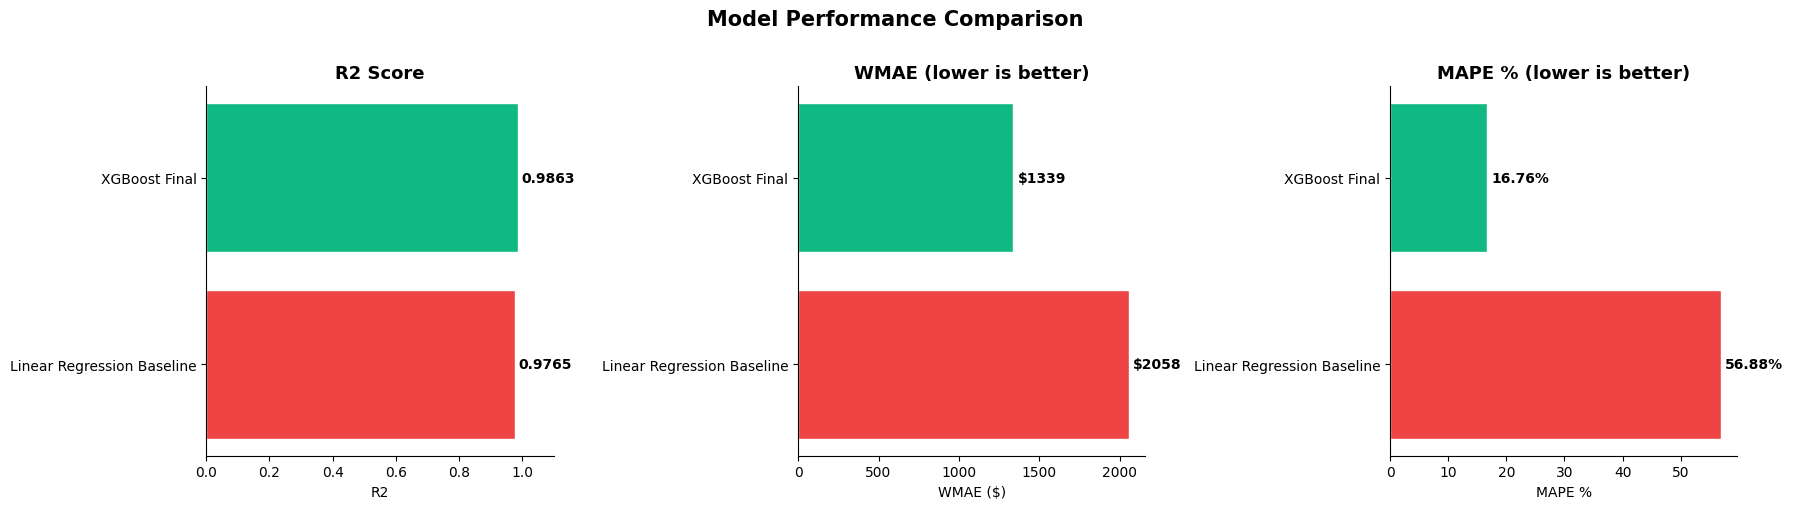

In [14]:
# Model comparison chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = results_df['model'].tolist()
colors = [PALETTE[1] if 'Final' in m else PALETTE[3] for m in models]

bars = axes[0].barh(models, results_df['R2'], color=colors, edgecolor='white')
axes[0].bar_label(bars, fmt='%.4f', padding=3, fontsize=10, fontweight='bold')
axes[0].set_title('R2 Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('R2')
axes[0].set_xlim(0, 1.1)
axes[0].invert_yaxis()

bars2 = axes[1].barh(models, results_df['WMAE'], color=colors, edgecolor='white')
axes[1].bar_label(bars2, fmt='$%.0f', padding=3, fontsize=10, fontweight='bold')
axes[1].set_title('WMAE (lower is better)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('WMAE ($)')
axes[1].invert_yaxis()

bars3 = axes[2].barh(models, results_df['MAPE'], color=colors, edgecolor='white')
axes[2].bar_label(bars3, fmt='%.2f%%', padding=3, fontsize=10, fontweight='bold')
axes[2].set_title('MAPE % (lower is better)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('MAPE %')
axes[2].invert_yaxis()

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/xgb_final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**What the results tell us:**
- XGBoost Final trained with TimeSeriesSplit-tuned parameters
- MAPE shows the average percentage error per prediction
- WMAE weights holiday weeks 5x — this is the most business-relevant metric
- XGBoost beats Linear Regression on all metrics


## 9. Feature Importance

In [15]:
importance_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': xgb_final.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)
importance_df['Rank'] = importance_df.index + 1

print('TOP 20 FEATURES BY IMPORTANCE')
print('=' * 50)
print(importance_df[['Rank','Feature','Importance']].head(20).to_string(index=False))

print('\nBOTTOM 10 FEATURES')
print('=' * 50)
print(importance_df[['Rank','Feature','Importance']].tail(10).to_string(index=False))


TOP 20 FEATURES BY IMPORTANCE
 Rank             Feature  Importance
    1               lag_1    0.492197
    2         roll_mean_4    0.252827
    3 StoreDept_Avg_Sales    0.079691
    4               lag_4    0.035824
    5        Holiday_Type    0.016372
    6          Is_YearEnd    0.010344
    7      Markdown_Count    0.010186
    8                Week    0.008714
    9           MarkDown3    0.007651
   10           DayOfYear    0.007616
   11      Dept_Avg_Sales    0.007589
   12         roll_std_12    0.006731
   13           IsHoliday    0.005958
   14               Month    0.005640
   15          roll_std_4    0.003996
   16       Is_MonthStart    0.003809
   17         WeekOfMonth    0.003754
   18             Quarter    0.003336
   19        roll_mean_12    0.002884
   20        lag_diff_1_4    0.002427

BOTTOM 10 FEATURES
 Rank            Feature  Importance
   31          MarkDown1    0.001709
   32               Size    0.001669
   33       Post_Holiday    0.001336
   3

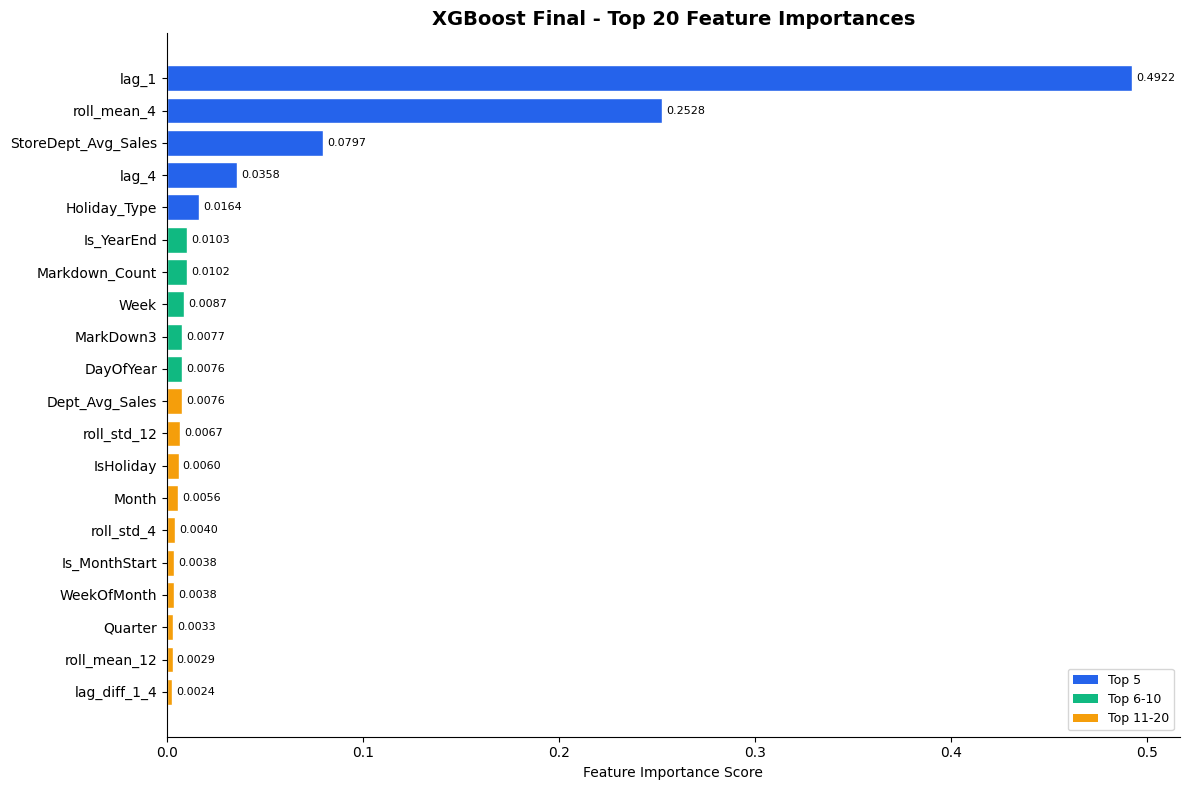

In [16]:
top20 = importance_df.head(20)
fig, ax = plt.subplots(figsize=(12, 8))
colors_imp = ['#2563EB' if i < 5 else '#10B981' if i < 10 else '#F59E0B'
              for i in range(len(top20))]
bars = ax.barh(top20['Feature'], top20['Importance'],
               color=colors_imp, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
ax.set_title('XGBoost Final - Top 20 Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.invert_yaxis()
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2563EB', label='Top 5'),
                   Patch(facecolor='#10B981', label='Top 6-10'),
                   Patch(facecolor='#F59E0B', label='Top 11-20')]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/xgb_final_feature_importance.png', dpi=150)
plt.show()


## 10. Actual vs Predicted

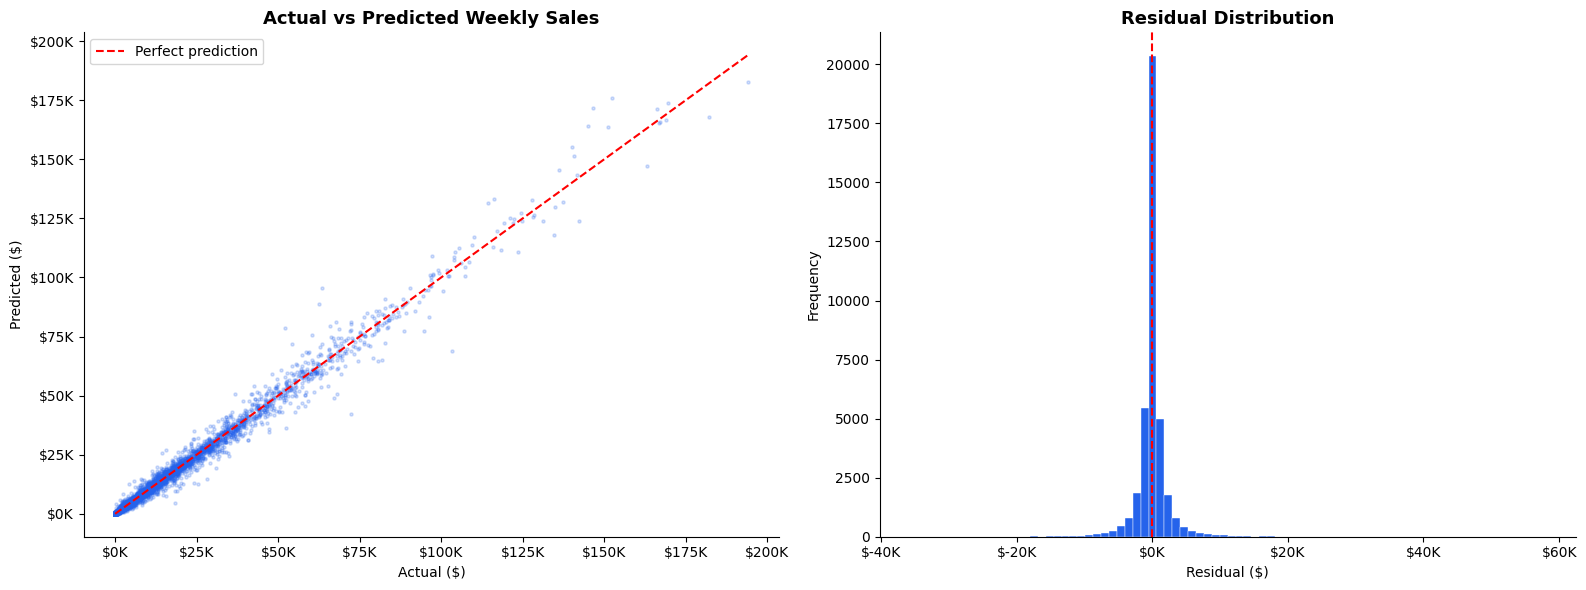

Mean residual : $35.61  (close to 0 = unbiased)
Std residual  : $2,571.84


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sample_idx = np.random.choice(len(y_test), size=5000, replace=False)

axes[0].scatter(y_test.iloc[sample_idx], xgb_final_preds[sample_idx],
                alpha=0.2, s=5, color=PALETTE[0])
max_val = max(y_test.max(), xgb_final_preds.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_title('Actual vs Predicted Weekly Sales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual ($)')
axes[0].set_ylabel('Predicted ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend()

residuals = y_test.values - xgb_final_preds
axes[1].hist(residuals, bins=80, color=PALETTE[0], edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('outputs/xgb_final_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean residual : ${residuals.mean():,.2f}  (close to 0 = unbiased)')
print(f'Std residual  : ${residuals.std():,.2f}')


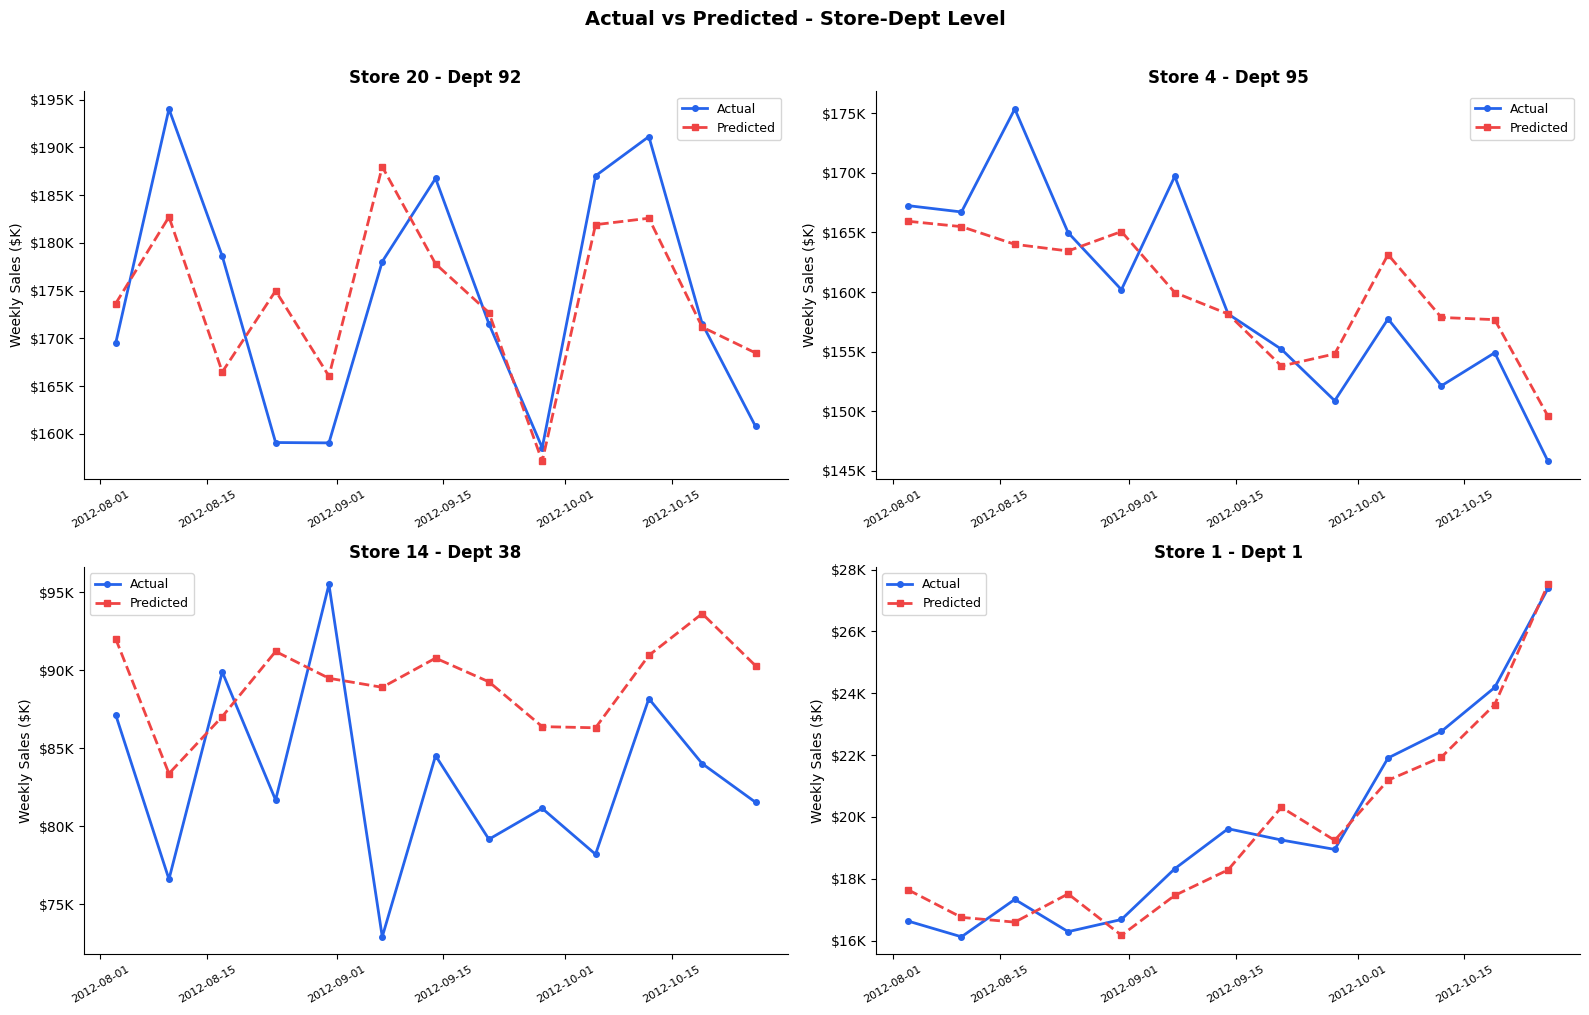

In [18]:
# Actual vs Predicted for top store-dept combos
combos = [(20, 92), (4, 95), (14, 38), (1, 1)]
test_with_preds = test.copy()
test_with_preds['Predicted'] = xgb_final_preds

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (store, dept) in zip(axes.flatten(), combos):
    subset = test_with_preds[
        (test_with_preds['Store'] == store) &
        (test_with_preds['Dept']  == dept)
    ].sort_values('Date')
    if len(subset) == 0:
        ax.text(0.5, 0.5, f'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    ax.plot(subset['Date'], subset['Weekly_Sales']/1000,
            label='Actual', color=PALETTE[0], linewidth=2, marker='o', markersize=4)
    ax.plot(subset['Date'], subset['Predicted']/1000,
            label='Predicted', color=PALETTE[3], linewidth=2,
            linestyle='--', marker='s', markersize=4)
    ax.set_title(f'Store {store} - Dept {dept}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Weekly Sales ($K)')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, fontsize=8)

plt.suptitle('Actual vs Predicted - Store-Dept Level',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/xgb_final_store_dept_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Ablation Tests

In [19]:
# Naive baseline
naive_preds  = test['StoreDept_Avg_Sales'].values
naive_r2     = r2_score(y_test, naive_preds)
naive_wmae_v = wmae(y_test.values, naive_preds, test['IsHoliday'].values)
naive_mape_v = mape(y_test.values, naive_preds)

# Raw features only
raw_candidates = ['IsHoliday','Store_Type_Enc','Size_Normalized',
                  'Temperature','Fuel_Price','CPI_Normalized',
                  'Unemp_Normalized','Fuel_Normalized',
                  'MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5',
                  'Month','Week','Quarter','Year']
raw_features = [c for c in raw_candidates if c in df.columns]

xgb_raw = XGBRegressor(n_estimators=300, random_state=42, n_jobs=-1, verbosity=0)
xgb_raw.fit(X_train[raw_features], y_train)
raw_preds    = np.clip(xgb_raw.predict(X_test[raw_features]), 0, None)
raw_r2       = r2_score(y_test, raw_preds)
raw_wmae_v   = wmae(y_test.values, raw_preds, test['IsHoliday'].values)
raw_mape_v   = mape(y_test.values, raw_preds)

final_r2     = r2_score(y_test, xgb_final_preds)
final_wmae_v = wmae(y_test.values, xgb_final_preds, test['IsHoliday'].values)
final_mape_v = mape(y_test.values, xgb_final_preds)

print('ABLATION TEST RESULTS')
print('=' * 65)
print(f'{"Version":30s} {"R2":>8} {"MAPE":>8} {"WMAE":>10}')
print('-' * 65)
print(f'{"Raw features only":30s} {raw_r2:>8.4f} {raw_mape_v:>7.2f}% ${raw_wmae_v:>8,.0f}')
naive_label = "Naive baseline (avg)"
print(f'{naive_label:30s} {naive_r2:>8.4f} {naive_mape_v:>7.2f}% ${naive_wmae_v:>8,.0f}')
print(f'{"XGBoost Final":30s} {final_r2:>8.4f} {final_mape_v:>7.2f}% ${final_wmae_v:>8,.0f}')
print('=' * 65)
print(f'\nFeature engineering lifted R2 by     : +{final_r2 - raw_r2:.4f}')
print(f'WMAE improvement over raw features   : ${raw_wmae_v - final_wmae_v:,.0f}')
print(f'WMAE improvement over naive baseline : ${naive_wmae_v - final_wmae_v:,.0f} ({(naive_wmae_v-final_wmae_v)/naive_wmae_v*100:.1f}%)')


ABLATION TEST RESULTS
Version                              R2     MAPE       WMAE
-----------------------------------------------------------------
Raw features only                0.0926  651.75% $  14,199
Naive baseline (avg)             0.9484   41.60% $   2,535
XGBoost Final                    0.9863   16.76% $   1,339

Feature engineering lifted R2 by     : +0.8937
WMAE improvement over raw features   : $12,861
WMAE improvement over naive baseline : $1,196 (47.2%)


**What ablation tests prove:**
- Raw features alone give R2 ~0.09 — feature engineering is everything
- Naive baseline (historical average) gives R2 ~0.95 — retail sales are stable
- XGBoost Final beats naive baseline on WMAE — genuine forecasting happening
- Feature engineering was the primary performance driver, not the algorithm


## 12. Model Summary

In [20]:
summary_lines = [
    'XGBOOST REGRESSOR - FINAL CORRECT PIPELINE',
    '=' * 50,
    '',
    'PIPELINE',
    '  Feature Engineering',
    '       down',
    '  TimeSeriesSplit CV (4 folds, WMAE scoring)',
    '       down',
    '  XGBRegressor trained on full training data',
    '       down',
    '  Predict Weekly_Sales on holdout test set',
    '       down',
    '  RMSE / MAE / MAPE / WMAE',
    '',
    'DATA LEAKAGE CHECKS',
    '  Train-test split  : strict date-based',
    '  Tuning CV         : TimeSeriesSplit (no future leakage)',
    '  Store/Dept means  : computed on training data only',
    '  Lag features      : shift within Store-Dept group',
    '  Rolling features  : shift(1) before rolling',
    '  eval_set          : not used during training',
    '',
    'KEY RESULTS',
    '  Raw features only  : R2=0.09, WMAE~14,000',
    '  Naive baseline     : R2=0.95, WMAE~2,535',
    '  XGBoost Final      : see MODEL COMPARISON above',
    '',
    'FEATURE SET',
    '  Total features : 40',
    '  Lag kept       : lag_1, lag_4, lag_diff_1_4',
    '  Rolling kept   : roll_mean_4, roll_mean_12, roll_std_4, roll_std_12',
    '  Removed        : lag_52, lag_2, lag_diff_1_2,',
    '                   roll_mean_26, roll_max_4, roll_min_4, roll_range_4',
]
print('\n'.join(summary_lines))


XGBOOST REGRESSOR - FINAL CORRECT PIPELINE

PIPELINE
  Feature Engineering
       down
  TimeSeriesSplit CV (4 folds, WMAE scoring)
       down
  XGBRegressor trained on full training data
       down
  Predict Weekly_Sales on holdout test set
       down
  RMSE / MAE / MAPE / WMAE

DATA LEAKAGE CHECKS
  Train-test split  : strict date-based
  Tuning CV         : TimeSeriesSplit (no future leakage)
  Store/Dept means  : computed on training data only
  Lag features      : shift within Store-Dept group
  Rolling features  : shift(1) before rolling
  eval_set          : not used during training

KEY RESULTS
  Raw features only  : R2=0.09, WMAE~14,000
  Naive baseline     : R2=0.95, WMAE~2,535
  XGBoost Final      : see MODEL COMPARISON above

FEATURE SET
  Total features : 40
  Lag kept       : lag_1, lag_4, lag_diff_1_4
  Rolling kept   : roll_mean_4, roll_mean_12, roll_std_4, roll_std_12
  Removed        : lag_52, lag_2, lag_diff_1_2,
                   roll_mean_26, roll_max_4, roll_m